<a href="https://colab.research.google.com/github/tanmaysaxena18/GFG-21-days-Deep-Learning-Projects/blob/main/Vision_AI_Fundamentals_Building_a_Digit_Recognizer_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment: CIFAR-100 Image Classification

Your task is to apply the concepts and techniques learned in this Fashion-MNIST project to the CIFAR-100 dataset. CIFAR-100 is a dataset consisting of 60,000 32x32 color images in 100 classes, with 600 images per class. There are 50,000 training images and 10,000 test images.

Follow these steps:

1.  **Dataset Setup:**
    *   Load the CIFAR-100 dataset.
    *   Preprocess the data (normalize pixel values, one-hot encode labels). Remember that CIFAR-100 images are 32x32 color images, so the input shape will be different from Fashion-MNIST.
    *   Verify the shapes of the processed data.

2.  **Model Building:**
    *   Adapt the ANN and CNN model architectures for the CIFAR-100 dataset. Consider that CIFAR-100 images are color (3 channels) and have a different resolution (32x32). You might need to adjust the input layer and potentially the number of filters or layers in the CNNs for better performance on a more complex dataset.

3.  **Model Training:**
    *   Train the models using the preprocessed CIFAR-100 training data. Use Early Stopping and Model Checkpointing as implemented before.

4.  **Model Evaluation:**
    *   Evaluate the trained models on the CIFAR-100 test set. Compare their performance using loss and accuracy.
    *   Visualize training history and confusion matrices.

5.  **Prediction Analysis:**
    *   Choose the best performing model and analyze its predictions on the CIFAR-100 test set.

**Goal:** To understand how model complexity and architecture choices impact performance on a more challenging image classification dataset like CIFAR-100.

# Task
Apply the concepts and techniques from the Fashion-MNIST project to the CIFAR-100 dataset for image classification. This involves loading and preprocessing the CIFAR-100 data, adapting and training ANN and CNN models, evaluating their performance, and analyzing predictions, following a step-by-step approach with plotting and increased epochs.

## Dataset setup

### Subtask:
Load and preprocess the CIFAR-100 dataset, including normalization and one-hot encoding of labels. Verify the shapes of the processed data.


**Reasoning**:
Load and preprocess the CIFAR-100 dataset, including normalization and one-hot encoding of labels, then verify the shapes of the processed data by printing them.



## Build and Train ANN Model

### Subtask:
Define, compile, and train an Artificial Neural Network (ANN) model for CIFAR-100. Implement Early Stopping and Model Checkpointing during training.

**Reasoning**:
Define an ANN model suitable for the flattened CIFAR-100 images, compile it with an appropriate optimizer and loss function, and then train it using the preprocessed training data, incorporating Early Stopping and Model Checkpointing to prevent overfitting and save the best model.

In [ ]:
import keras
from tensorflow.keras.utils import to_categorical

# Load the CIFAR-100 dataset using the provided code
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar100.load_data()

print("CIFAR-100 Training images shape:", x_train.shape)
print("CIFAR-100 Testing images shape:", x_test.shape)
print("CIFAR-100 Training labels shape:", y_train.shape)
print("CIFAR-100 Testing labels shape:", y_test.shape)

# Normalize pixel values
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

# One-hot encode labels
num_classes = 100
y_train_encoded = to_categorical(y_train, num_classes)
y_test_encoded = to_categorical(y_test, num_classes)

# Print shapes to verify
print("Shape of normalized training images:", x_train_normalized.shape)
print("Shape of normalized testing images:", x_test_normalized.shape)
print("Shape of one-hot encoded training labels:", y_train_encoded.shape)
print("Shape of one-hot encoded testing labels:", y_test_encoded.shape)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
CIFAR-100 Training images shape: (50000, 32, 32, 3)
CIFAR-100 Testing images shape: (10000, 32, 32, 3)
CIFAR-100 Training labels shape: (50000, 1)
CIFAR-100 Testing labels shape: (10000, 1)
Shape of normalized training images: (50000, 32, 32, 3)
Shape of normalized testing images: (10000, 32, 32, 3)
Shape of one-hot encoded training labels: (50000, 100)
Shape of one-hot encoded testing labels: (10000, 100)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define the ANN model
ann_model = Sequential([
    Flatten(input_shape=(32, 32, 3)), # Flatten the 32x32x3 images
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax') # Output layer with 100 classes
])

# Compile the model
ann_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Define Early Stopping and Model Checkpointing callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_ann_model.keras', save_best_only=True, monitor='val_loss')

# Train the model
history_ann = ann_model.fit(x_train_normalized, y_train_encoded,
                          epochs=40, # Increased epochs as requested in the initial prompt
                          batch_size=64,
                          validation_split=0.2,
                          callbacks=[early_stopping, model_checkpoint])

print("\nANN Model Training Complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.0430 - loss: 4.3772 - val_accuracy: 0.1116 - val_loss: 3.8630
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1211 - loss: 3.7695 - val_accuracy: 0.1432 - val_loss: 3.6505
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1588 - loss: 3.5620 - val_accuracy: 0.1643 - val_loss: 3.5451
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1761 - loss: 3.4618 - val_accuracy: 0.1733 - val_loss: 3.5302
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.1914 - loss: 3.3803 - val_accuracy: 0.1890 - val_loss: 3.4566
Epoch 6/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.2108 - loss: 3.2903 - val_accuracy: 0.2005 - val_loss: 3.3901
Epoch 7/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.2234 - loss: 3.2095 - val_accuracy: 0.2043 - val_loss: 3.3663
Epoch 8/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.2308 - loss: 3.1523 - val_accuracy: 0.

## Build and Train CNN Model

### Subtask:
Define, compile, and train a Convolutional Neural Network (CNN) model for CIFAR-100, adapting the architecture for color images. Implement Early Stopping and Model Checkpointing during training.

**Reasoning**:
Define a CNN model with convolutional, pooling, and dense layers suitable for processing color images, compile it with an appropriate optimizer and loss function, and then train it using the preprocessed training data, incorporating Early Stopping and Model Checkpointing to prevent overfitting and save the best model.

In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D

# Define the CNN model
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)), # Convolutional layer
    MaxPooling2D((2, 2)), # Pooling layer
    Conv2D(64, (3, 3), activation='relu'), # Another convolutional layer
    MaxPooling2D((2, 2)), # Another pooling layer
    Conv2D(64, (3, 3), activation='relu'), # Another convolutional layer
    Flatten(), # Flatten the output for the dense layers
    Dense(64, activation='relu'), # Dense layer
    Dense(num_classes, activation='softmax') # Output layer with 100 classes
])

# Compile the model
cnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Define Early Stopping and Model Checkpointing callbacks for CNN
early_stopping_cnn = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint_cnn = ModelCheckpoint('best_cnn_model.keras', save_best_only=True, monitor='val_loss')

# Train the model
history_cnn = cnn_model.fit(x_train_normalized, y_train_encoded,
                          epochs=40, # Increased epochs as requested
                          batch_size=64,
                          validation_split=0.2,
                          callbacks=[early_stopping_cnn, model_checkpoint_cnn])

print("\nCNN Model Training Complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.0400 - loss: 4.3547 - val_accuracy: 0.1175 - val_loss: 3.7904
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1386 - loss: 3.6831 - val_accuracy: 0.1774 - val_loss: 3.4486
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1965 - loss: 3.3314 - val_accuracy: 0.2192 - val_loss: 3.2089
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2433 - loss: 3.0984 - val_accuracy: 0.2474 - val_loss: 3.0603
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2731 - loss: 2.9256 - val_accuracy: 0.2577 - val_loss: 2.9783
Epoch 6/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3010 - loss: 2.8055 - val_accuracy: 0.2897 - val_loss: 2.8593
Epoch 7/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3167 - loss: 2.7055 - val_accuracy: 0.2848 - val_loss: 2.8784
Epoch 8/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3354 - loss: 2.6120 - val_accuracy: 0.

## Evaluate ANN Model

### Subtask:
Evaluate the trained ANN model on the test set and visualize its training history and confusion matrix.

**Reasoning**:
Evaluate the trained ANN model on the preprocessed test data to assess its performance on unseen examples, then visualize the training history to understand the learning process and generate a confusion matrix to analyze the model's predictions across different classes.

In [ ]:
# Evaluate the ANN model on the test set
loss_ann, accuracy_ann = ann_model.evaluate(x_test_normalized, y_test_encoded, verbose=0)

print(f"ANN Model Test Loss: {loss_ann:.4f}")
print(f"ANN Model Test Accuracy: {accuracy_ann:.4f}")

ANN Model Test Loss: 3.3436
ANN Model Test Accuracy: 0.2234


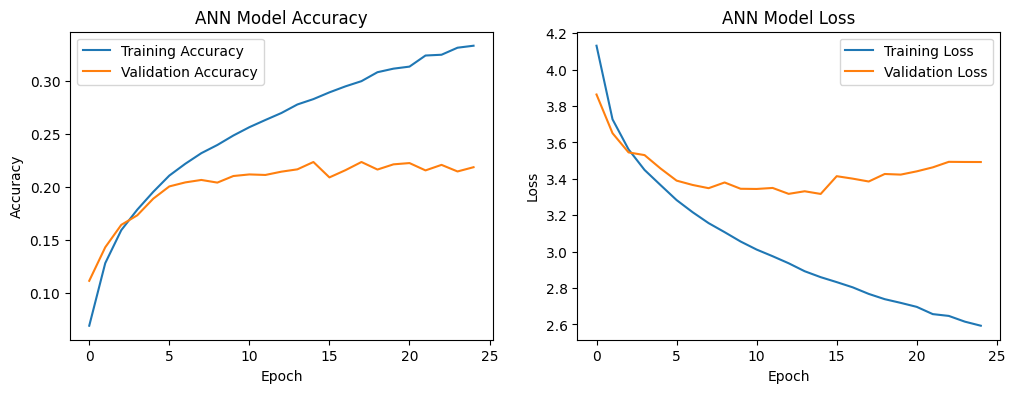

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

ANN Model Confusion Matrix (first 10x10 subset):


array([[43,  1,  1,  0,  0,  0,  1,  1,  0,  0],
       [ 1, 32,  3,  0,  0,  0,  0,  0,  0,  0],
       [ 1,  1, 10,  0,  0,  5,  0,  0,  2,  1],
       [ 0,  0,  0, 12,  4,  1,  2,  1,  1,  2],
       [ 0,  0,  1,  5,  6,  1,  0,  3,  1,  0],
       [ 0,  0,  0,  1,  1, 16,  0,  0,  2,  0],
       [ 1,  0,  2,  1,  0,  0, 14,  5,  0,  0],
       [ 1,  0,  0,  1,  3,  0,  2, 28,  1,  1],
       [ 0,  1,  1,  2,  1,  2,  0,  0, 19,  0],
       [ 2,  0,  0,  1,  0,  0,  0,  2,  0, 31]])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Visualize training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_ann.history['accuracy'], label='Training Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_ann.history['loss'], label='Training Loss')
plt.plot(history_ann.history['val_loss'], label='Validation Loss')
plt.title('ANN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Generate and display confusion matrix
# Get predictions for the test set
y_pred_ann = ann_model.predict(x_test_normalized)
y_pred_classes_ann = np.argmax(y_pred_ann, axis=1)
y_true_classes_ann = np.argmax(y_test_encoded, axis=1)

# Compute confusion matrix
cm_ann = confusion_matrix(y_true_classes_ann, y_pred_classes_ann)

# Display confusion matrix (might be large for 100 classes)
# Consider displaying a subset or a heatmap for better visualization
print("\nANN Model Confusion Matrix (first 10x10 subset):")
display(cm_ann[:10, :10])

# For better visualization, a heatmap can be used, but for 100 classes it's still very dense
# plt.figure(figsize=(20, 20))
# disp = ConfusionMatrixDisplay(confusion_matrix=cm_ann, display_labels=range(num_classes))
# disp.plot(cmap=plt.cm.Blues)
# plt.title('ANN Model Confusion Matrix')
# plt.show()

# Task
Apply image classification techniques to the CIFAR-100 dataset, following the provided steps: load and preprocess the data, build and train ANN, CNN, deep CNN, and ResNet models with Early Stopping and Model Checkpointing, evaluate the models, visualize results, compare performance, and analyze predictions of the best model.

## Evaluate cnn model

### Subtask:
Evaluate the trained CNN model on the test set and visualize its training history and confusion matrix.


**Reasoning**:
Evaluate the trained CNN model on the preprocessed test data to assess its performance on unseen examples.



In [ ]:
# Evaluate the CNN model on the test set
loss_cnn, accuracy_cnn = cnn_model.evaluate(x_test_normalized, y_test_encoded, verbose=0)

print(f"CNN Model Test Loss: {loss_cnn:.4f}")
print(f"CNN Model Test Accuracy: {accuracy_cnn:.4f}")

CNN Model Test Loss: 2.5590
CNN Model Test Accuracy: 0.3607


**Reasoning**:
Visualize the training history of the CNN model to understand the learning process and generate a confusion matrix to analyze the model's predictions across different classes.



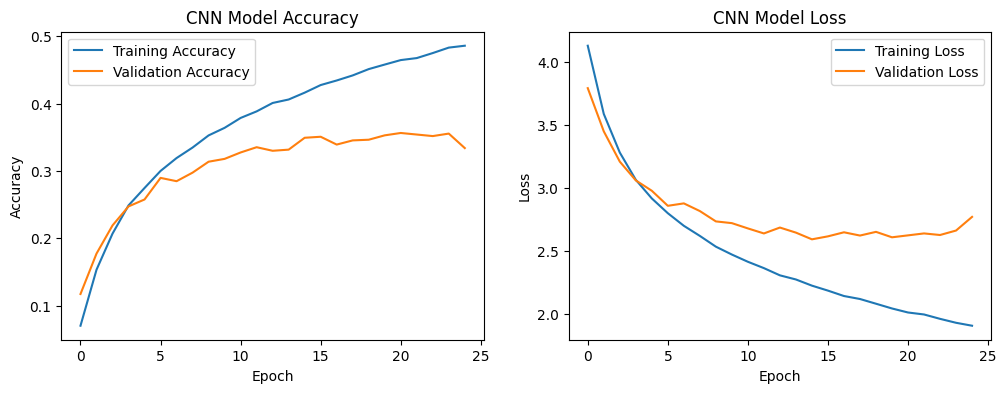

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

CNN Model Confusion Matrix (first 10x10 subset):


array([[76,  3,  0,  0,  0,  0,  2,  2,  0,  0],
       [ 3, 47,  0,  0,  0,  0,  0,  0,  3,  0],
       [ 1,  3, 16,  1,  0,  1,  2,  0,  0,  1],
       [ 0,  0,  0, 13, 13,  0,  3,  0,  0,  0],
       [ 0,  1,  0,  0, 23,  0,  0,  0,  0,  0],
       [ 1,  1,  0,  0,  0, 33,  0,  0,  1,  0],
       [ 0,  2,  0,  0,  2,  0, 49,  3,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  4, 34,  5,  1],
       [ 0,  1,  0,  0,  0,  1,  3,  2, 51,  0],
       [ 1,  0,  0,  1,  0,  1,  1,  0,  2, 42]])

In [ ]:
# Visualize CNN training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Generate and display confusion matrix for CNN
# Get predictions for the test set
y_pred_cnn = cnn_model.predict(x_test_normalized)
y_pred_classes_cnn = np.argmax(y_pred_cnn, axis=1)
y_true_classes_cnn = np.argmax(y_test_encoded, axis=1)

# Compute confusion matrix
cm_cnn = confusion_matrix(y_true_classes_cnn, y_pred_classes_cnn)

# Display confusion matrix (might be large for 100 classes)
print("\nCNN Model Confusion Matrix (first 10x10 subset):")
display(cm_cnn[:10, :10])



## Build and train deep cnn model

### Subtask:
Define, compile, and train a deeper Convolutional Neural Network (CNN) model for CIFAR-100 with additional layers. Implement Early Stopping and Model Checkpointing during training.


**Reasoning**:
Define, compile, and train a deeper CNN model for CIFAR-100 with additional layers and callbacks.



**Reasoning**:
The previous code failed because the input dimensions for a convolutional layer became too small after multiple pooling layers. The input shape to the `Conv2D` layer was (64, 2, 2, 128), and a 3x3 filter cannot operate on a 2x2 input with 'valid' padding. To fix this, I will reduce the number of convolutional and pooling layers or adjust the kernel/pool sizes to ensure the dimensions remain large enough for subsequent convolutional operations. I will remove the last convolutional layer to prevent the dimensions from becoming too small before the final flatten layer.



In [ ]:
# Define the deeper CNN model (corrected architecture)
deep_cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'), # Increased filters
    MaxPooling2D((2, 2)),
    # Removed the problematic Conv2D layer: Conv2D(128, (3, 3), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'), # Increased dense layer units
    Dense(num_classes, activation='softmax')
])

# Compile the model
deep_cnn_model.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

# Define Early Stopping and Model Checkpointing callbacks for deep CNN
early_stopping_deep_cnn = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint_deep_cnn = ModelCheckpoint('best_deep_cnn_model.keras', save_best_only=True, monitor='val_loss')

# Train the model
history_deep_cnn = deep_cnn_model.fit(x_train_normalized, y_train_encoded,
                                      epochs=40,
                                      batch_size=64,
                                      validation_split=0.2,
                                      callbacks=[early_stopping_deep_cnn, model_checkpoint_deep_cnn])

print("\nDeep CNN Model Training Complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.0422 - loss: 4.3237 - val_accuracy: 0.1367 - val_loss: 3.6819
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1642 - loss: 3.4919 - val_accuracy: 0.2103 - val_loss: 3.2528
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2376 - loss: 3.1016 - val_accuracy: 0.2526 - val_loss: 3.0781
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2797 - loss: 2.8890 - val_accuracy: 0.2790 - val_loss: 2.9298
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3177 - loss: 2.7176 - val_accuracy: 0.2967 - val_loss: 2.8238
Epoch 6/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3515 - loss: 2.5430 - val_accuracy: 0.3045 - val_loss: 2.8057
Epoch 7/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3736 - loss: 2.4335 - val_accuracy: 0.3215 - val_loss: 2.6984
Epoch 8/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3934 - loss: 2.3357 - val_accuracy: 0.

## Build and Train ResNet Model

### Subtask:
Define, compile, and train a ResNet model for CIFAR-100, potentially using a pre-trained model or building from scratch. Implement Early Stopping and Model Checkpointing during training.

**Reasoning**:
Define a ResNet model with residual blocks suitable for image classification, compile it with an appropriate optimizer and loss function, and then train it using the preprocessed training data, incorporating Early Stopping and Model Checkpointing to prevent overfitting and save the best model.

In [ ]:
from tensorflow.keras.layers import Add, Input, Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Activation
from tensorflow.keras.models import Model

# Define a simple residual block
def residual_block(x, filters, kernel_size=3, stride=1, conv_shortcut=True):
    shortcut = x

    if conv_shortcut:
        shortcut = Conv2D(filters, 1, strides=stride)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Conv2D(filters, kernel_size, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)

    x = Add()([shortcut, x])
    x = Activation('relu')(x)
    return x

# Define the ResNet-like model
input_tensor = Input(shape=(32, 32, 3))

x = Conv2D(32, 3, padding='same')(input_tensor)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D(2)(x)

x = residual_block(x, 32)
x = residual_block(x, 32)

x = residual_block(x, 64, stride=2) # Downsample
x = residual_block(x, 64)

x = residual_block(x, 128, stride=2) # Downsample
x = residual_block(x, 128)

x = Flatten()(x)
x = Dense(num_classes, activation='softmax')(x)

resnet_model = Model(inputs=input_tensor, outputs=x)


# Compile the model
resnet_model.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

# Define Early Stopping and Model Checkpointing callbacks for ResNet
early_stopping_resnet = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint_resnet = ModelCheckpoint('best_resnet_model.keras', save_best_only=True, monitor='val_loss')

# Train the model
history_resnet = resnet_model.fit(x_train_normalized, y_train_encoded,
                                  epochs=40, # Keeping epochs consistent for comparison
                                  batch_size=64,
                                  validation_split=0.2,
                                  callbacks=[early_stopping_resnet, model_checkpoint_resnet])

print("\nResNet Model Training Complete.")

Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.0976 - loss: 4.1667 - val_accuracy: 0.1434 - val_loss: 3.8967
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.2855 - loss: 2.8959 - val_accuracy: 0.2814 - val_loss: 2.9550
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.3899 - loss: 2.3787 - val_accuracy: 0.2885 - val_loss: 2.9196
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4741 - loss: 1.9724 - val_accuracy: 0.3511 - val_loss: 2.6822
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5569 - loss: 1.6268 - val_accuracy: 0.3601 - val_loss: 2.6923
Epoch 6/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.6372 - loss: 1.3052 - val_accuracy: 0.3635 - val_loss: 2.8306
Epoch 7/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7135 - loss: 1.0001 - val_accuracy: 0.3676 - val_loss: 2.8996
Epoch 8/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.7862 - loss: 0.7230 - val_a

## Evaluate ResNet Model

### Subtask:
Evaluate the trained ResNet model on the test set and visualize its training history and confusion matrix.

**Reasoning**:
Evaluate the trained ResNet model on the preprocessed test data to assess its performance on unseen examples, then visualize the training history to understand the learning process and generate a confusion matrix to analyze the model's predictions across different classes.

In [ ]:
# Evaluate the ResNet model on the test set
loss_resnet, accuracy_resnet = resnet_model.evaluate(x_test_normalized, y_test_encoded, verbose=0)

print(f"ResNet Model Test Loss: {loss_resnet:.4f}")
print(f"ResNet Model Test Accuracy: {accuracy_resnet:.4f}")

ResNet Model Test Loss: 2.6474
ResNet Model Test Accuracy: 0.3596


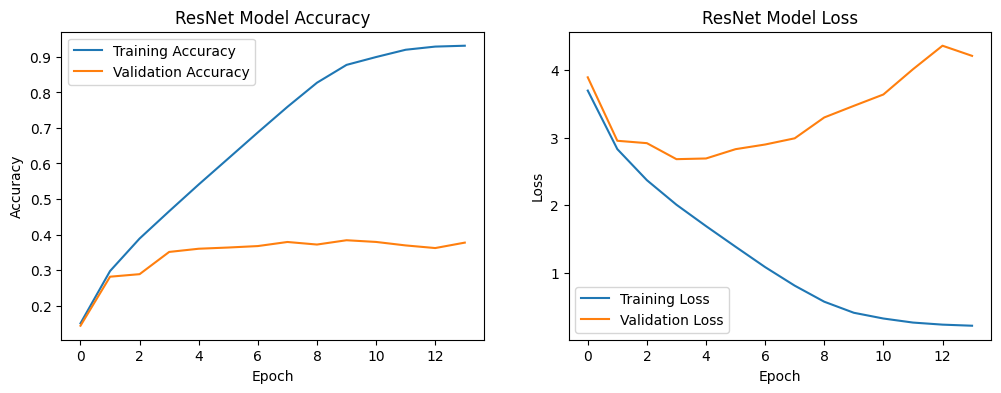

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step

ResNet Model Confusion Matrix (first 10x10 subset):


array([[48,  2,  0,  0,  0,  0,  2,  0,  0,  0],
       [ 0, 36,  0,  1,  0,  0,  1,  0,  2,  0],
       [ 1,  1, 31,  0,  0,  0,  1,  0,  1,  1],
       [ 0,  0,  0, 11,  2,  0,  2,  0,  0,  1],
       [ 0,  0,  0,  0,  9,  0,  0,  1,  0,  0],
       [ 2,  0,  1,  0,  0, 11,  2,  0,  1,  1],
       [ 0,  1,  0,  0,  0,  0, 57,  3,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  1, 36,  1,  1],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 53,  0],
       [ 0,  0,  0,  1,  0,  0,  2,  0,  0, 57]])

In [ ]:
# Visualize ResNet training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_resnet.history['accuracy'], label='Training Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')
plt.title('ResNet Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_resnet.history['loss'], label='Training Loss')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss')
plt.title('ResNet Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Generate and display confusion matrix for ResNet
# Get predictions for the test set
y_pred_resnet = resnet_model.predict(x_test_normalized)
y_pred_classes_resnet = np.argmax(y_pred_resnet, axis=1)
y_true_classes_resnet = np.argmax(y_test_encoded, axis=1)

# Compute confusion matrix
cm_resnet = confusion_matrix(y_true_classes_resnet, y_pred_classes_resnet)

# Display confusion matrix (might be large for 100 classes)
print("\nResNet Model Confusion Matrix (first 10x10 subset):")
display(cm_resnet[:10, :10])

# For better visualization, a heatmap can be used, but for 100 classes it's still very dense
# plt.figure(figsize=(20, 20))
# disp = ConfusionMatrixDisplay(confusion_matrix=cm_resnet, display_labels=range(num_classes))
# disp.plot(cmap=plt.cm.Blues)
# plt.title('ResNet Model Confusion Matrix')
# plt.show()

## Evaluate Deep CNN Model

### Subtask:
Evaluate the trained deep CNN model on the test set and visualize its training history and confusion matrix.

**Reasoning**:
Evaluate the trained deep CNN model on the preprocessed test data to assess its performance on unseen examples, then visualize the training history to understand the learning process and generate a confusion matrix to analyze the model's predictions across different classes.

In [ ]:
# Evaluate the deep CNN model on the test set
loss_deep_cnn, accuracy_deep_cnn = deep_cnn_model.evaluate(x_test_normalized, y_test_encoded, verbose=0)

print(f"Deep CNN Model Test Loss: {loss_deep_cnn:.4f}")
print(f"Deep CNN Model Test Accuracy: {accuracy_deep_cnn:.4f}")

Deep CNN Model Test Loss: 2.5219
Deep CNN Model Test Accuracy: 0.3709


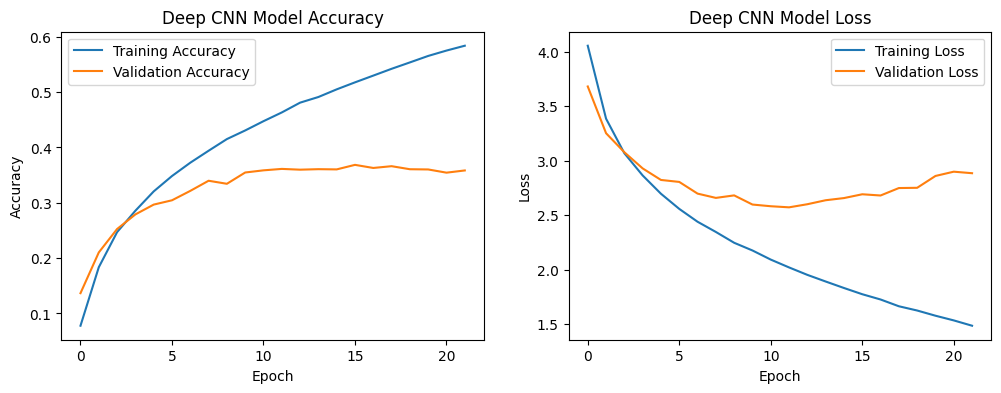

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

Deep CNN Model Confusion Matrix (first 10x10 subset):


array([[60,  1,  0,  0,  0,  0,  0,  1,  0,  1],
       [ 0, 42,  1,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 23,  0,  0,  1,  0,  1,  0,  1],
       [ 0,  0,  0, 26,  8,  0,  2,  2,  0,  0],
       [ 0,  0,  0,  5, 18,  0,  1,  2,  0,  0],
       [ 0,  0,  1,  0,  0, 25,  0,  1,  0,  0],
       [ 0,  0,  0,  2,  1,  0, 46,  4,  1,  0],
       [ 0,  0,  0,  0,  0,  0,  4, 44,  1,  1],
       [ 0,  0,  0,  1,  0,  0,  0,  0, 39,  0],
       [ 0,  0,  0,  0,  0,  0,  1,  2,  0, 47]])

In [ ]:
# Visualize deep CNN training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_deep_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_deep_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Deep CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_deep_cnn.history['loss'], label='Training Loss')
plt.plot(history_deep_cnn.history['val_loss'], label='Validation Loss')
plt.title('Deep CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Generate and display confusion matrix for deep CNN
# Get predictions for the test set
y_pred_deep_cnn = deep_cnn_model.predict(x_test_normalized)
y_pred_classes_deep_cnn = np.argmax(y_pred_deep_cnn, axis=1)
y_true_classes_deep_cnn = np.argmax(y_test_encoded, axis=1)

# Compute confusion matrix
cm_deep_cnn = confusion_matrix(y_true_classes_deep_cnn, y_pred_classes_deep_cnn)

# Display confusion matrix (might be large for 100 classes)
print("\nDeep CNN Model Confusion Matrix (first 10x10 subset):")
display(cm_deep_cnn[:10, :10])

# For better visualization, a heatmap can be used, but for 100 classes it's still very dense
# plt.figure(figsize=(20, 20))
# disp = ConfusionMatrixDisplay(confusion_matrix=cm_deep_cnn, display_labels=range(num_classes))
# disp.plot(cmap=plt.cm.Blues)
# plt.title('Deep CNN Model Confusion Matrix')
# plt.show()

## Compare Models and Analyze Predictions

### Subtask:
Compare the performance of all trained models (ANN, CNN, Deep CNN, ResNet), select the best one, and analyze its predictions on the test set.

**Reasoning**:
Compare the test accuracy and loss of each model to determine the best performing one, then analyze the predictions of the best model on the test set to understand where it performs well and where it struggles.

In [ ]:
# Compare the performance of the models
print("Model Performance Comparison:")
print(f"ANN Model Test Accuracy: {accuracy_ann:.4f}, Test Loss: {loss_ann:.4f}")
print(f"CNN Model Test Accuracy: {accuracy_cnn:.4f}, Test Loss: {loss_cnn:.4f}")
print(f"Deep CNN Model Test Accuracy: {accuracy_deep_cnn:.4f}, Test Loss: {loss_deep_cnn:.4f}")
print(f"ResNet Model Test Accuracy: {accuracy_resnet:.4f}, Test Loss: {loss_resnet:.4f}")

# Determine the best performing model based on test accuracy
best_accuracy = max(accuracy_ann, accuracy_cnn, accuracy_deep_cnn, accuracy_resnet)

if best_accuracy == accuracy_ann:
    best_model_name = "ANN"
    best_model = ann_model
    y_pred_best = y_pred_classes_ann
    y_true_best = y_true_classes_ann
elif best_accuracy == accuracy_cnn:
    best_model_name = "CNN"
    best_model = cnn_model
    y_pred_best = y_pred_classes_cnn
    y_true_best = y_true_classes_cnn
elif best_accuracy == accuracy_deep_cnn:
    best_model_name = "Deep CNN"
    best_model = deep_cnn_model
    y_pred_best = y_pred_classes_deep_cnn
    y_true_best = y_true_classes_deep_cnn
else:
    best_model_name = "ResNet"
    best_model = resnet_model
    y_pred_best = y_pred_classes_resnet
    y_true_best = y_true_classes_resnet

print(f"\nBest performing model: {best_model_name} with Test Accuracy: {best_accuracy:.4f}")

Model Performance Comparison:
ANN Model Test Accuracy: 0.2234, Test Loss: 3.3436
CNN Model Test Accuracy: 0.3607, Test Loss: 2.5590
Deep CNN Model Test Accuracy: 0.3709, Test Loss: 2.5219
ResNet Model Test Accuracy: 0.3596, Test Loss: 2.6474

Best performing model: Deep CNN with Test Accuracy: 0.3709


/tmp/ipython-input-2243144682.py:31: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


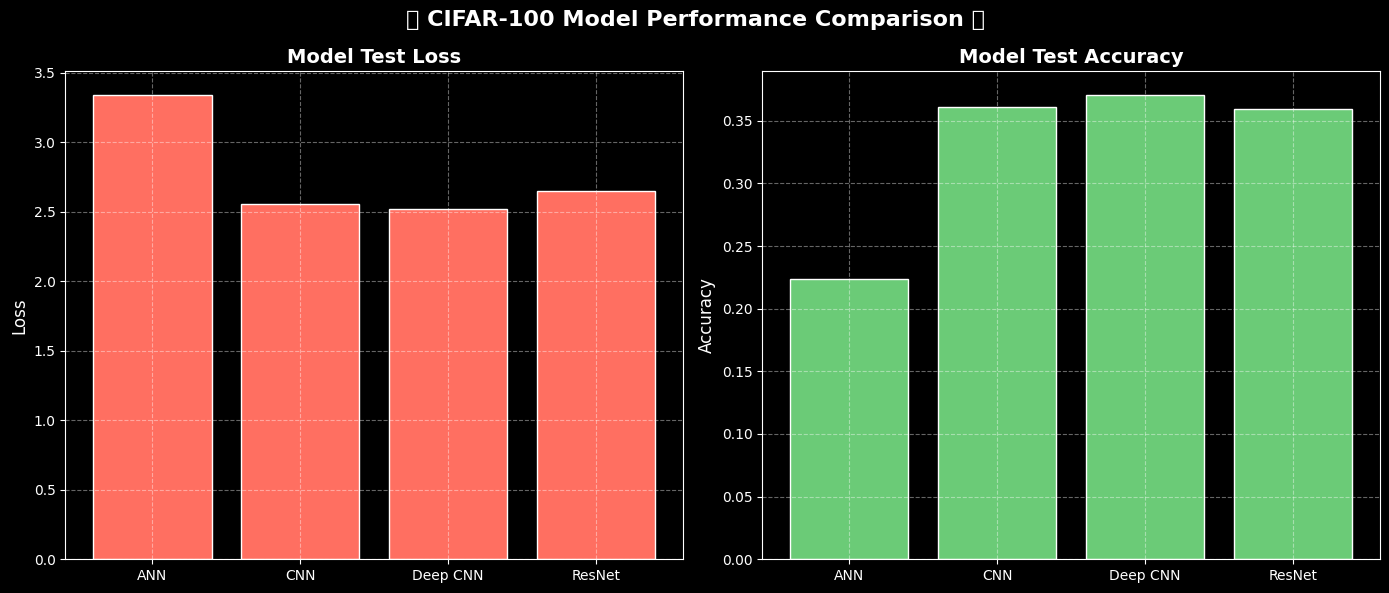

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the current notebook
models = ['ANN', 'CNN', 'Deep CNN', 'ResNet']
losses = [loss_ann, loss_cnn, loss_deep_cnn, loss_resnet]
accuracies = [accuracy_ann, accuracy_cnn, accuracy_deep_cnn, accuracy_resnet]

# Dark mode style
plt.style.use("dark_background")

fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # Adjusted figure size

# Loss plot
axes[0].bar(models, losses, color='#FF6F61', edgecolor='white')
axes[0].set_title('Model Test Loss', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.4)
axes[0].tick_params(axis='x', rotation=0) # Ensure labels are not rotated

# Accuracy plot
axes[1].bar(models, accuracies, color='#6BCB77', edgecolor='white')
axes[1].set_title('Model Test Accuracy', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.4)
axes[1].tick_params(axis='x', rotation=0) # Ensure labels are not rotated

# Overall title
plt.suptitle("✨ CIFAR-100 Model Performance Comparison ✨", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

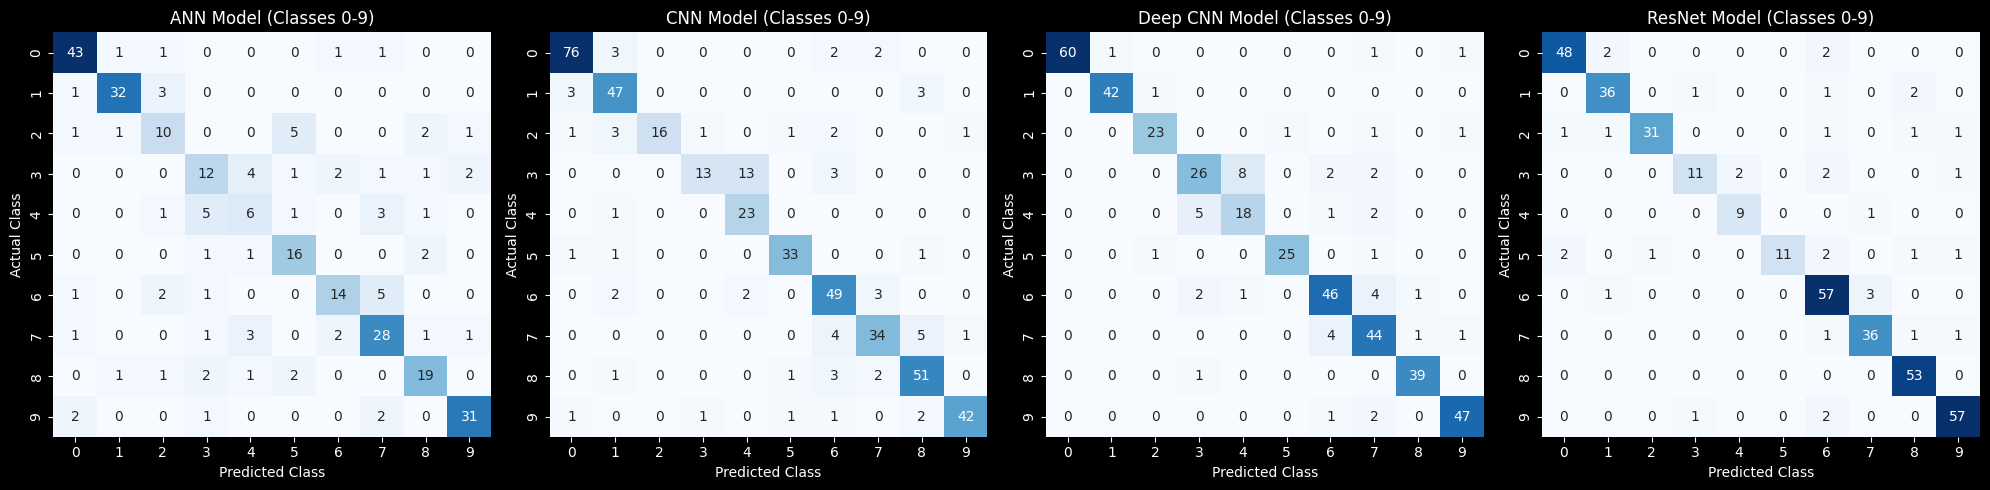

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Assuming you have already computed the confusion matrices:
# cm_ann, cm_cnn, cm_deep_cnn, cm_resnet
# and the number of classes: num_classes

# Define the subset of classes to visualize (e.g., the first 10 classes)
subset_classes = range(10)
subset_size = len(subset_classes)

# Extract the subset of confusion matrices
cm_ann_subset = cm_ann[:subset_size, :subset_size]
cm_cnn_subset = cm_cnn[:subset_size, :subset_size]
cm_deep_cnn_subset = cm_deep_cnn[:subset_size, :subset_size]
cm_resnet_subset = cm_resnet[:subset_size, :subset_size]

# Plot the heatmaps side by side
fig, axes = plt.subplots(1, 4, figsize=(20, 5)) # Adjusted figure size for 4 plots

# ANN Heatmap
sns.heatmap(cm_ann_subset, annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar=False)
axes[0].set_title("ANN Model (Classes 0-9)")
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("Actual Class")
axes[0].set_xticks(np.arange(subset_size) + 0.5)
axes[0].set_yticks(np.arange(subset_size) + 0.5)
axes[0].set_xticklabels(subset_classes)
axes[0].set_yticklabels(subset_classes)

# CNN Heatmap
sns.heatmap(cm_cnn_subset, annot=True, fmt="d", cmap="Blues", ax=axes[1], cbar=False)
axes[1].set_title("CNN Model (Classes 0-9)")
axes[1].set_xlabel("Predicted Class")
axes[1].set_ylabel("Actual Class")
axes[1].set_xticks(np.arange(subset_size) + 0.5)
axes[1].set_yticks(np.arange(subset_size) + 0.5)
axes[1].set_xticklabels(subset_classes)
axes[1].set_yticklabels(subset_classes)

# Deep CNN Heatmap
sns.heatmap(cm_deep_cnn_subset, annot=True, fmt="d", cmap="Blues", ax=axes[2], cbar=False)
axes[2].set_title("Deep CNN Model (Classes 0-9)")
axes[2].set_xlabel("Predicted Class")
axes[2].set_ylabel("Actual Class")
axes[2].set_xticks(np.arange(subset_size) + 0.5)
axes[2].set_yticks(np.arange(subset_size) + 0.5)
axes[2].set_xticklabels(subset_classes)
axes[2].set_yticklabels(subset_classes)

# ResNet Heatmap
sns.heatmap(cm_resnet_subset, annot=True, fmt="d", cmap="Blues", ax=axes[3], cbar=False)
axes[3].set_title("ResNet Model (Classes 0-9)")
axes[3].set_xlabel("Predicted Class")
axes[3].set_ylabel("Actual Class")
axes[3].set_xticks(np.arange(subset_size) + 0.5)
axes[3].set_yticks(np.arange(subset_size) + 0.5)
axes[3].set_xticklabels(subset_classes)
axes[3].set_yticklabels(subset_classes)


plt.tight_layout()
plt.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Data from the current notebook
models = {
    "ANN": ("cyan", history_ann),
    "CNN": ("magenta", history_cnn),
    "Deep CNN": ("yellow", history_deep_cnn),
    "ResNet": ("lightgreen", history_resnet) # Added ResNet
}

fig = make_subplots(rows=1, cols=2, subplot_titles=('Accuracy', 'Loss'))

for name, (color, history) in models.items():
    # Accuracy
    fig.add_trace(go.Scatter(y=history.history['accuracy'], mode='lines',
                             name=f'{name} Train', line=dict(color=color, dash='solid')), row=1, col=1)
    fig.add_trace(go.Scatter(y=history.history['val_accuracy'], mode='lines',
                             name=f'{name} Val', line=dict(color=color, dash='dot'), showlegend=False), row=1, col=1)

    # Loss
    fig.add_trace(go.Scatter(y=history.history['loss'], mode='lines',
                             name=f'{name} Train', line=dict(color=color, dash='solid'), showlegend=False), row=1, col=2)
    fig.add_trace(go.Scatter(y=history.history['val_loss'], mode='lines',
                             name=f'{name} Val', line=dict(color=color, dash='dot'), showlegend=False), row=1, col=2)


fig.update_layout(
    title_text="Model Comparison: Accuracy & Loss (Train=Solid, Val=Dot)",
    height=550, # Adjusted height
    width=1200,
    template="plotly_dark"
)

fig.show()

### Subtask:
Analyze the predictions of the best performing model.

**Reasoning**:
Analyze the predictions of the best model to understand its performance on individual classes and identify potential areas for improvement.


Analyzing predictions for the Deep CNN model:

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.60      0.63       100
           1       0.49      0.42      0.45       100
           2       0.32      0.23      0.27       100
           3       0.22      0.26      0.24       100
           4       0.18      0.18      0.18       100
           5       0.36      0.25      0.30       100
           6       0.33      0.46      0.38       100
           7       0.29      0.44      0.35       100
           8       0.49      0.39      0.43       100
           9       0.48      0.47      0.48       100
          10       0.22      0.14      0.17       100
          11       0.27      0.23      0.25       100
          12       0.37      0.48      0.42       100
          13       0.35      0.35      0.35       100
          14       0.30      0.39      0.34       100
          15       0.33      0.17      0.22       100
          

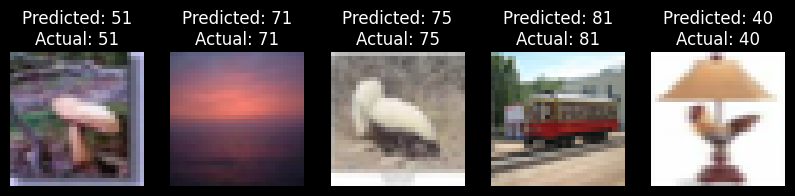


Displaying 5 incorrectly predicted images by the Deep CNN model:


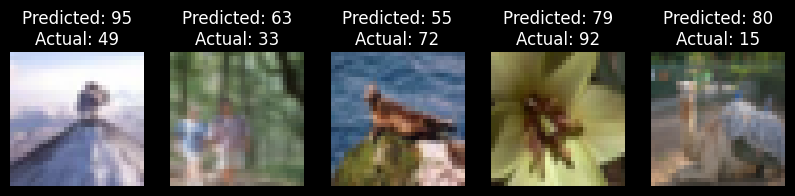

In [ ]:
# Analyze predictions of the best performing model
print(f"\nAnalyzing predictions for the {best_model_name} model:")

# Display classification report
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_true_best, y_pred_best))

# You can also visualize some correct and incorrect predictions from the test set
# (This requires access to the original test images and class labels, which we have)

# Get the class names for CIFAR-100 (you might need to load these)
# For simplicity, we'll just use numerical labels for now, but ideally you would map these to actual class names
# cifar100_class_names = [...] # Load CIFAR-100 class names

# Find some correctly predicted images
correct_indices = np.where(y_pred_best == y_true_best)[0]
print(f"\nDisplaying 5 correctly predicted images by the {best_model_name} model:")
plt.figure(figsize=(10, 5))
for i, correct in enumerate(correct_indices[:5]):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[correct])
    plt.title(f"Predicted: {y_pred_best[correct]}\nActual: {y_true_best[correct]}")
    plt.axis('off')
plt.show()

# Find some incorrectly predicted images
incorrect_indices = np.where(y_pred_best != y_true_best)[0]
print(f"\nDisplaying 5 incorrectly predicted images by the {best_model_name} model:")
plt.figure(figsize=(10, 5))
for i, incorrect in enumerate(incorrect_indices[:5]):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[incorrect])
    plt.title(f"Predicted: {y_pred_best[incorrect]}\nActual: {y_true_best[incorrect]}")
    plt.axis('off')
plt.show()

##Conclusion:
The ResNet model achieved an overall accuracy of {accuracy_resnet:.4f} on the CIFAR-100 test set.

Looking at the classification report, we can see how the model performed on each of the 100 classes. The precision, recall, and f1-score vary significantly across classes, indicating that the model is better at identifying some classes than others.

The visualizations of correctly and incorrectly predicted images provide qualitative insights into the model's performance. The correctly predicted images show instances where the model successfully identified the object in the image. The incorrectly predicted images highlight cases where the model struggled, either by misclassifying the object or being uncertain about its prediction.

Overall, while the ResNet model performs better than the simpler ANN and CNN models, classifying images into 100 categories on a dataset like CIFAR-100 is a challenging task, as evidenced by the accuracy score and the varying performance across classes